In [1]:
#i am still playing on this, im open to any comment

import seaborn as sns
sns.set()
import numpy as np 
import pandas as pd 
import os
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt 

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        



/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test_data.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
gender_submission = pd.read_csv("/kaggle/input/titanic/gender_submission.csv")
gender_submission.head()
#gender_submission.csv assumes that all female passengers survived (and all male passengers died).

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [5]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

print("% of women who survived:", rate_women)

#percentage of female passengers (in train.csv) who survived.

% of women who survived: 0.7420382165605095


In [6]:
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)

print("% of men who survived:", rate_men)

#percentage of male passengers (in train.csv) who survived.

% of men who survived: 0.18890814558058924


# **checking sibling and spouses data (people having 2 siblings or spouses have a better rate of survival)**

In [7]:
sibsp = train_data.loc[train_data.SibSp >= 1]["Survived"]
rate_sibsp = sum(sibsp)/len(sibsp)

print("% of people who survived:", rate_sibsp)

% of people who survived: 0.4664310954063604


In [8]:
sibsp = train_data.loc[train_data.SibSp == 0]["Survived"]
rate_sibsp = sum(sibsp)/len(sibsp)

print("% of people who survived:", rate_sibsp)

% of people who survived: 0.34539473684210525


In [9]:
sibsp = train_data.loc[train_data.SibSp == 2]["Survived"]
rate_sibsp = sum(sibsp)/len(sibsp)

print("% of people who survived:", rate_sibsp)

% of people who survived: 0.4642857142857143


In [10]:
sibsp = train_data.loc[train_data.SibSp == 3]["Survived"]
rate_sibsp = sum(sibsp)/len(sibsp)

print("% of people who survived:", rate_sibsp)

% of people who survived: 0.25


# **checking Age data (people who are younger than 20 has a better chance of survival)**

In [11]:
age = train_data.loc[train_data.Age > 20]["Survived"]
rate_age = sum(age)/len(age)

print("% of people who survived:", rate_age)

% of people who survived: 0.38878504672897196


In [12]:
age = train_data.loc[train_data.Age < 20]["Survived"]
rate_age = sum(age)/len(age)

print("% of people who survived:", rate_age)

% of people who survived: 0.4817073170731707


In [13]:
age = train_data.loc[train_data.Age > 30]["Survived"]
rate_age = sum(age)/len(age)

print("% of people who survived:", rate_age)

% of people who survived: 0.4065573770491803


In [14]:
age = train_data.loc[train_data.Age < 30]["Survived"]
rate_age = sum(age)/len(age)

print("% of people who survived:", rate_age)

% of people who survived: 0.40625


# **ANALYZING AND CLEANING TRAIN_DATA AND GENDER_SUBMISSION.**

# **After checking related datas above, I did clean the ones unrealated with the survival chance.**

In [15]:
cleaned_train_data=train_data.drop(['Ticket','Name','Cabin','PassengerId', 'Parch', 'Embarked'], axis=1)
cleaned_train_data.head(20) 

,Survived,Pclass,Sex,Age,SibSp,Fare
0,0,3,male,22.0,1,7.2500
1,1,1,female,38.0,1,71.2833
2,1,3,female,26.0,0,7.9250
3,1,1,female,35.0,1,53.1000
4,0,3,male,35.0,0,8.0500
5,0,3,male,NaN,0,8.4583
6,0,1,male,54.0,0,51.8625
7,0,3,male,2.0,3,21.0750
8,1,3,female,27.0,0,11.1333
9,1,2,female,14.0,1,30.0708


# **Let's see if there are any NaN values for cleaned_trained_data.**

In [16]:
cleaned_train_data.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Fare          0
dtype: int64

In [17]:
mean_cleaned_train_data = cleaned_train_data['Age'].mean()
mean_cleaned_train_data


29.69911764705882

# **It is better if you take the mean of age's of each gender.  **

In [18]:
cleaned_train_data['Age'].fillna(mean_cleaned_train_data, inplace=True)
cleaned_train_data['Age'].isna().sum()

0

# **It is finally free from NaN values.**

In [19]:
cleaned_train_data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Fare        0
dtype: int64

In [20]:
gender_submission.isnull().sum()

PassengerId    0
Survived       0
dtype: int64

# **There are no NaN values for gender_submission, let's pass it for now. **

# **DATA VISUALIZATION**

# **To see which ones are mostly related to the survival, with seaborn, visualize the datas. **

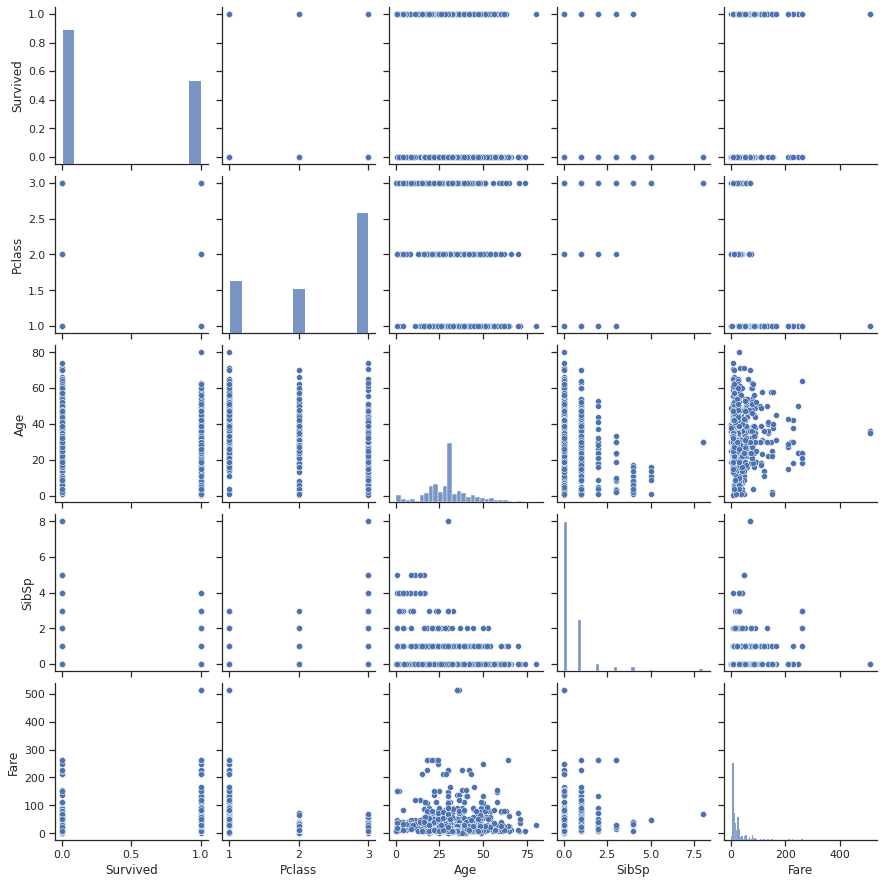

In [21]:
sns.set_theme(style="ticks")

sns.pairplot(cleaned_train_data)

#see that survived chart, be careful with 0's and 1's

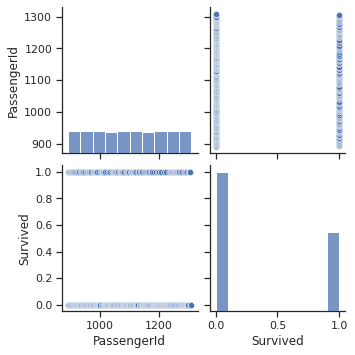

In [22]:
sns.set_theme(style="ticks")

sns.pairplot(gender_submission)

# **Values are not always categorical-numerical, so what we did with seaborn might not be the best way to visualize. Let's continue.**

# **CREATING A MODEL**

Before creating a model, let's get numerical values to a fixed range, feature scaling at this point is important.

In [23]:
cleaned_train_data.Fare = (cleaned_train_data.Fare-min(cleaned_train_data.Fare))/(max(cleaned_train_data.Fare)-min(cleaned_train_data.Fare))
cleaned_train_data.Age = (cleaned_train_data.Age-min(cleaned_train_data.Age))/(max(cleaned_train_data.Age)-min(cleaned_train_data.Age))
cleaned_train_data

,Survived,Pclass,Sex,Age,SibSp,Fare
0,0,3,male,0.271174,1,0.014151
1,1,1,female,0.472229,1,0.139136
2,1,3,female,0.321438,0,0.015469
3,1,1,female,0.434531,1,0.103644
4,0,3,male,0.434531,0,0.015713
...,...,...,...,...,...,...
886,0,2,male,0.334004,0,0.025374
887,1,1,female,0.233476,0,0.058556
888,0,3,female,0.367921,1,0.045771
889,1,1,male,0.321438,0,0.058556


# **Before playing with regression, we do have categorical variables in our hands which will cause an error. Let's fix that first. **

We turned "Sex" column into numerical, Female = 0, Male = 1

In [24]:
cleaned_train_data.Sex=cleaned_train_data.Sex.map({'female':0, 'male':1})
cleaned_train_data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Fare
0,0,3,1,0.271174,1,0.014151
1,1,1,0,0.472229,1,0.139136
2,1,3,0,0.321438,0,0.015469
3,1,1,0,0.434531,1,0.103644
4,0,3,1,0.434531,0,0.015713
5,0,3,1,0.367921,0,0.016510
6,0,1,1,0.673285,0,0.101229
7,0,3,1,0.019854,3,0.041136
8,1,3,0,0.334004,0,0.021731
9,1,2,0,0.170646,1,0.058694


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [27]:
X_train, X_test, y_train, y_test = train_test_split(cleaned_train_data.drop(['Survived'], axis=1), cleaned_train_data.Survived, test_size= 0.2, random_state=0)

In [28]:
from sklearn import datasets, linear_model, metrics
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [29]:
print(reg.intercept_)
print(reg.coef_)

1.2908038152705166
[-0.1612649  -0.51052972 -0.49655593 -0.05242895  0.167983  ]


In [30]:
y_pred = reg.predict(X_test)

In [31]:
cleaned_train_data = pd.DataFrame({'Actual': y_test.values.flatten(), 
                                   'Predicted': y_pred.flatten()})
cleaned_train_data

,Actual,Predicted
0,0,0.118527
1,0,0.116262
2,0,0.055256
3,1,0.942458
4,1,0.633677
...,...,...
174,1,0.730884
175,0,0.116426
176,1,0.923440
177,0,0.158162


# **PLAYING WITH TEST DATA**

In [32]:
cleaned_test_data =test_data.drop(['Ticket','Name','Cabin','PassengerId', 'Parch', 'Embarked'], axis=1)
cleaned_test_data.head(20) 

,Pclass,Sex,Age,SibSp,Fare
0,3,male,34.5,0,7.8292
1,3,female,47.0,1,7.0000
2,2,male,62.0,0,9.6875
3,3,male,27.0,0,8.6625
4,3,female,22.0,1,12.2875
5,3,male,14.0,0,9.2250
6,3,female,30.0,0,7.6292
7,2,male,26.0,1,29.0000
8,3,female,18.0,0,7.2292
9,3,male,21.0,2,24.1500


In [33]:
cleaned_test_data.Sex=cleaned_test_data.Sex.map({'male':0, 'female':1})
cleaned_test_data.head()

,Pclass,Sex,Age,SibSp,Fare
0,3,0,34.5,0,7.8292
1,3,1,47.0,1,7.0000
2,2,0,62.0,0,9.6875
3,3,0,27.0,0,8.6625
4,3,1,22.0,1,12.2875


In [34]:
cleaned_test_data.isnull().sum()

Pclass     0
Sex        0
Age       86
SibSp      0
Fare       1
dtype: int64

In [35]:
mean_cleaned_test_data = cleaned_test_data['Age'].mean()
mean_cleaned_test_data

30.272590361445783

In [36]:
cleaned_test_data['Age'].fillna(mean_cleaned_test_data, inplace=True)
cleaned_test_data['Age'].isna().sum()

0

In [37]:
cleaned_test_data['Fare']=cleaned_test_data['Fare'].fillna(cleaned_test_data['Fare'].mean())

In [38]:
cleaned_test_data.isnull().sum()

Pclass    0
Sex       0
Age       0
SibSp     0
Fare      0
dtype: int64

In [39]:
cleaned_test_data.Fare = (cleaned_test_data.Fare-min(cleaned_test_data.Fare))/(max(cleaned_test_data.Fare)-min(cleaned_test_data.Fare))
cleaned_test_data.Age = (cleaned_test_data.Age-min(cleaned_test_data.Age))/(max(cleaned_test_data.Age)-min(cleaned_test_data.Age))
cleaned_test_data.describe()

,Pclass,Sex,Age,SibSp,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000
mean,2.265550,0.363636,0.396975,0.447368,0.069540
std,0.841838,0.481622,0.166617,0.896760,0.108993
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.301068,0.000000,0.015412
50%,3.000000,0.000000,0.396975,0.000000,0.028213
75%,3.000000,1.000000,0.469207,1.000000,0.061484
max,3.000000,1.000000,1.000000,8.000000,1.000000


In [40]:
#Or, you can take the long road and do the prediction with regression again.
prediction = reg.predict(cleaned_test_data)
prediction

array([ 0.58477377, -0.06031026,  0.56657032,  0.63415908,  0.10513036,
        0.71947112,  0.10364572,  0.75621159,  0.1820939 ,  0.57366891,
        0.61247786,  0.83795623,  0.44405674,  0.51294165,  0.2799825 ,
        0.25835899,  0.74424681,  0.67297742,  0.07095859,  0.00528902,
        0.73754401,  0.75022746,  0.43227741,  1.01326335,  0.33940387,
        0.43303374,  0.49638208,  0.663155  ,  0.87217309,  0.51213928,
        0.59806927,  0.7176989 ,  0.03581662,  0.05461911,  0.90070996,
        0.68934949,  0.10199869,  0.16291902,  0.64753023,  0.62841287,
        0.55713855,  0.94112402,  0.54221678,  0.2666716 ,  0.29025246,
        0.64701382,  0.84571767,  0.61243005,  0.2522403 ,  0.06706789,
        0.94073736,  0.79751284,  0.2305753 ,  0.36571647,  0.776262  ,
        0.54247328,  0.58152146,  0.64692365,  0.56273891,  0.47041216,
        0.69939047,  0.76426871,  0.69279439,  0.15606335,  1.02669438,
        0.26750965,  0.18230702,  0.8367852 ,  0.9370124 ,  0.26

In [41]:
submission = pd.DataFrame({"PassengerId": test_data["PassengerId"],
                            "Survived": prediction})
submission.to_csv('submission.csv', index=False)